# IMDb Sentiment Analysis — Text Preprocessing & Tokenization

This notebook is part of a small Natural Language Processing project built using TensorFlow and Keras.  
The workflow in this notebook focuses on preparing the IMDb movie reviews dataset for modeling through text preprocessing, tokenization, and exploratory analysis.

The structure, ideas, and preprocessing techniques are inspired by the YouTube course  
**“Natural Language Processing with TensorFlow 2 — Beginners Course”**  
(https://www.youtube.com/watch?v=B2q5cRJvqI8&t=175s).

### In this notebook, we:
- Set up the `TextVectorization` layer for tokenization and vocabulary generation  
- Converted raw text into integer sequences  
- Decoded sequences back into text for inspection  
- Built a clean batching pipeline for training and analysis  
- Generated word clouds for positive and negative sentiment classes  
- Created bar charts showing the top 20 most frequent words per sentiment  
- Established a reusable preprocessing workflow for future model architectures (LSTM, GRU, CNN, BiLSTM)

This notebook serves as the foundation for all subsequent modeling steps in the project.


### Importing the libraries

In [10]:
import io
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import tensorflow_datasets as tfds

### Loading the IMDb Dataset

In this step we load the IMDb movie reviews dataset using `tensorflow_datasets`. The command returns the training data, test data, and some metadata about the dataset. We also set `as_supervised=True` so each element comes as a pair: `(text, label)`.

In [12]:
(train_data, test_data), info = tfds.load("imdb_reviews",
                                         split=(tfds.Split.TRAIN, tfds.Split.TEST),
                                         with_info=True,
                                         as_supervised=True)


### Before starting make inferences about the train_data, let's see how one or five observations look like 'text string' using:

* `train_data.take(n)` pulls the first `n` observations
* `.numpy()` converts the TensorFlow tensor to a NumPy string.
* `.decode("utf-8")` turns the byte string into normal text.

In [13]:
## Showing the first 5 review with their labels.
for text, label in train_data.take(5):
  print("Review:")
  print(text.numpy().decode("utf-8"))
  print("Label:", label.numpy())
  print("---------")

Review:
This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but this must simply be their worst role in history. Even their great acting could not redeem this movie's ridiculous storyline. This movie is an early nineties US propaganda piece. The most pathetic scenes were those when the Columbian rebels were making their cases for revolutions. Maria Conchita Alonso appeared phony, and her pseudo-love affair with Walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning. I am disappointed that there are movies like this, ruining actor's like Christopher Walken's good name. I could barely sit through it.
Label: 0
---------
Review:
I have been known to fall asleep during films, but this is usually due to a combination of things including, really tired, being warm and comfortable on the sette and having just eaten a lot. However on this occasion I fell asleep because the film was rub

I0000 00:00:1779813384.827198   14367 tf_record_dataset_op.cc:396] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 8388608
W0000 00:00:1779813384.835751   14372 cache_dataset_ops.cc:912] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


In this context, one could infer that `0 -> negative review` and `1 -> positive review`.

Let's now visualize the frequency of positive and negative revieww, for both `train_data` and `test_data`

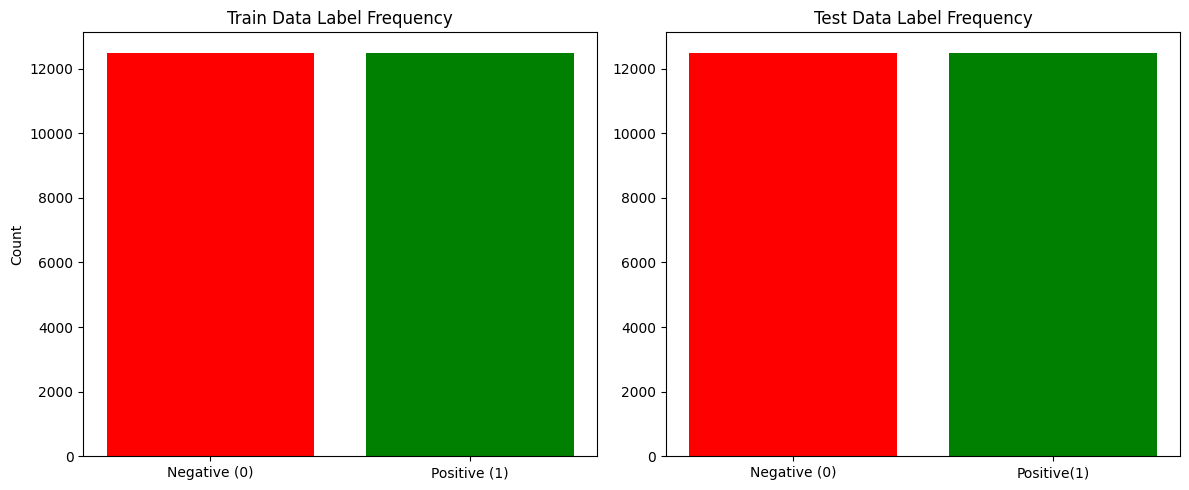

Train - Negative: 12500 Positive 12500
Test -Negative 12500 Positive: 12500


In [14]:
## Side by side frequency plot (train on the left, test on the right)

# Count labels for train_data
train_neg = 0
train_pos = 0
for _, label in train_data:
  if label.numpy() == 0:
    train_neg += 1
  else:
    train_pos += 1

# Count labels for the test_data
test_neg = 0
test_pos = 0
for _, label in test_data:
  if label.numpy() == 0:
    test_neg += 1
  else:
    test_pos += 1

# Plot side by side
plt.figure(figsize=(12, 5))

# Left plot: Train data
plt.subplot(1, 2, 1)
plt.bar(["Negative (0)", "Positive (1)"], [train_neg, train_pos], color = ["red", "green"])
plt.title("Train Data Label Frequency")
plt.ylabel("Count")

# Right plot: Test data
plt.subplot(1, 2, 2)
plt.bar(["Negative (0)", "Positive(1)"], [test_neg, test_pos], color=["red","green"])
plt.title("Test Data Label Frequency")

plt.tight_layout()
plt.show()

print("Train - Negative:", train_neg, "Positive", train_pos)
print("Test -Negative", test_neg, "Positive:", test_pos)

The IMDb dataset is **perfectly balanced** with 12,500 negative and 12,500 positive reviews in both train and test splits.

The dataset is clean and ready for vectorization and modeling, following the next steps (only for this dataset):

* No class imbalance -> no nedd for class weights.
* Your model will train without bias toward one label.
* Accuracy will be a meaningful metric (not inflated by imbalance)

### Preparing the Training (Testing) Text for the Vectorizer

Before creating the text vectorization layer, we extract only the text from the training dataset. This gives us a clean sequence of raw text that the vectorizer will use to learn the vocabulary.

Here is a little description of what we're adoinfin each step

### Vectorizer

TensorFlow performs **four operations automatically**
1. `Lowercasing`. All text becomes lowercase so "Movie" and "movie" are treated the same.
2. `Tokenization` Teh text is split into individuals words (tokens).
    Example: "This movies was amazing!" -> ["this", "movie", "was", "amazing"]
3. `Vocabulary lookup` Each word is replaced with an integer ID based on the vocabulary learned during `adapt()`.
    Example: ["this", "movie", "was", "amazing"] -> [12, 87, 45, 133]
    The numbers correspond to the most frequent words in the dataset.
4. `Padding/truncation` in the next step, we're going to set `output_sequence_lenght = 200`, so it means every review becomes **exactly 200 integers**:
    * If the review is shorter -> padded with zeros
    * If the review is longer -> truncated
        Example: [12, 86, 45, 133] -> [12, 87, 45, 133, 0, 0, 0, ... ,0] (length 200)

## How to calculate `sequence_lenght=200` is a good option for this dataset. Follow the following steps:

* Step 1. Compute the lenght of each review (in tokens)
* Step 2. Plot the distribution of review lenghts
* Step 3. Interpert the plot
* Step 4. Print summary statistics

In [15]:
## Compute the lenght of each review (in tokens)

# Collect lenghts of all reviews
lengths = []
for text, _ in train_data:
  # Convert tensor -> Python string
  review = text.numpy().decode("utf-8")
  # Count tokens by splitting on whitespace
  lengths.append(len(review.split()))

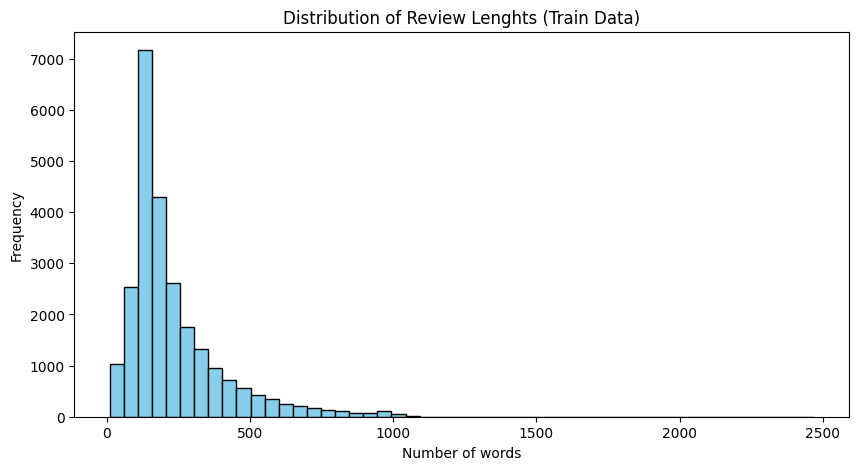

In [16]:
# Plot the distribution of review
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=50, color="skyblue", edgecolor="black")
plt.title("Distribution of Review Lenghts (Train Data)")
plt.xlabel("Number of words")
plt.ylabel("Frequency")
plt.show()

The distribution reveals three important things:

* **The peak is around 100-150 words** This means the majority of reviews are comfortably shorter than 200.
* **The frequency drops sharply after ~200 words** Only a small fraction of reviews are longer than 200, so truncation affects very few samples.
* **The long tail (300-1000 + words) is rare** These long reviews exist,, but they are outliers and don't justify increasing the sequence length for the entire dataset.

In [17]:
from tensorflow.python.ops.math_ops import np
# Print summary statistics
print("Mean length:", np.mean(lengths))
print("Median length:", np.median(lengths))
print("90th percentile:", np.percentile(lengths, 90))
print("95th percentile:", np.percentile(lengths, 95))
print("Max length:", np.max(lengths))

Mean length: 233.7872
Median length: 174.0
90th percentile: 458.0
95th percentile: 598.0
Max length: 2470


## Create the TextVectorization layer

We define how text will be transformed into integer sequences.

In [18]:
from tensorflow.keras.layers import TextVectorization

sequence_length = 200
max_tokens = 20000 # a common default; you can adjust later

vectorizer_layer = TextVectorization(
    max_tokens=max_tokens,
    output_mode="int",
    output_sequence_length=sequence_length
)

## Extract the Raw Training Text & Explain `adapt()`

`train_text` is a dataset containing **only the text**, without label.

This is required because `TextVectorization.adapt()` expects a dataset of **strings only**.

`adapt()` **trains the vocabulary so the vectorizer knows how to turn text into numbers**, following those steps:

      * Reads **every review** in your training set
      * Splits text into tokens (words)
      * Counts how often each word appears
      * Builds a `vocabulary` of the most frequente words (up to `max_tokens`)
      * Assigs each word a unique integer ID
      * Prepare itself to vonvert text -> sequences of integers

In [19]:
train_text = train_data.map(lambda x, y: x)
vectorizer_layer.adapt(train_text)

## Vectorize the dataset using a function + mapping.

### The vectorize_text is a function such as:
* Takes a `(text, label)` pair
* Applies `vectorize_layer(text)` -> each review becomes a vector of lenght `200`
* Returns `(vectorized_text, label)` so labels stay attached

### `.map(vectorize_text)`:
* Applies this transformation to **every example** in `train_data` and `test_data`
* After this, `train_ds` and `test_ds` are ready for batching and model training, because they now contain `only numbers`, not raw strings.

In [20]:
# Defining the function and apply to train and text data
def vectorize_text(text, label):
  text = vectorizer_layer(text)
  return text, label

train_ds = train_data.map(vectorize_text)
test_ds = test_data.map(vectorize_text)

## Explanation of batching (shuffle, bathc, prefetch)

### `.shuffle(1000)`
* Keeps a buffer of 1000 examples and randmly draws from it.
* Ensures each epoch sees the data in a different order.
* Helps the model generalize better (prevents learning form a fixed sequence)

### `.batch(10)`
* Groups 10 examples into one batch.
* Input shape becomes `(batch_size, sequence_length)` -> `(10,200)`
* The model updates its weights once per batch instead of conce per example

### `.prefetch(tf.data.AUTOTUNE)`
* Overlaps data loading with model training
* While the model trains on batch n, the pipeline prepares batch n+1
* Makes training faster and smoother.

In [21]:
# Here we turn the vectorized dataset into mini-batches that the model can train on efficiently.

train_batches = (
    train_ds
    .shuffle(1000)   # randomize order of examples
    .batch(10)  # groups of 10
    .prefetch(tf.data.AUTOTUNE)
)

test_batches = (
    test_ds
    .batch(10)
    .prefetch(tf.data.AUTOTUNE)
)

## Batch insopection & diagnostics  

This section verifies that the preprocessing pipeline is working correctly before training the modle.

* Sample a random batch
* inspect one sequence
* Plot the sequence
* Count label frequencies
* Confrirm shuffling behavior

In [22]:
# take one batch from the dataset
for batch_x, batch_y in train_batches.take(1):
  sample_sequences = batch_x.numpy()
  sample_labels = batch_y.numpy()

This step extracts a single batch from the training pipeline. Because we used `.batch(10)`, each batch contains **10 sequences**, each of length **200**. We convert the tensors to Numpy arrays so we can inspect and maniopulate them easily.

In [23]:
# Pick a random index from the batch
idx = np.random.randint(0, sample_sequences.shape[0])

print("Random sequence (first 50 tokens):")
print(sample_sequences[idx][:50])
print("\nLabel:", sample_labels[idx])

Random sequence (first 50 tokens):
[  48    7    4  221    5 5582   60  139   28 3272   46   43    4  135
  394    8    2   18  113 4778 3615    2  564    5 9601 1393 9053   31
  212   12   14    2  393  334   21    2  244   27   14  147   60 1129
    2    1 7252  564   60    1   13   27]

Label: 1


Here we randomly select one sequence from the batch and print the first 50 tokens. This helps confirm:

* the sequence is exactly **200 tokens long**
* Padding is applied correctly
* Tokens are integers representing vocabulary IDs
* The label is either **0 (negative)** or **1 (positive)**

This is your first sanity check that the vectorizer is working.

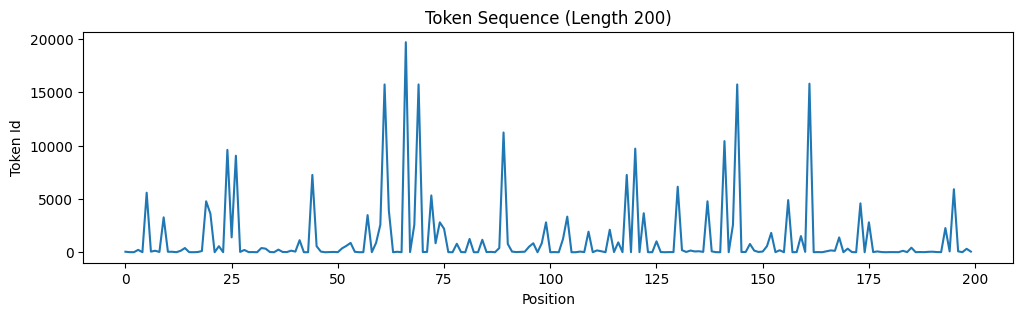

In [24]:
# Plot the sequence
plt.figure(figsize=(12, 3))
plt.plot(sample_sequences[idx])
plt.title("Token Sequence (Length 200)")
plt.xlabel("Position")
plt.ylabel("Token Id")
plt.show()

Plotting the sequence gives a quick visual diagnostic:

* The padded region appears as a flat line of zeros
* The non-padded region shows varying token IDs
* You can visually confirm the sequence length and padding behavior.

This is especially useful for spotting preprocessing mistakes early.

In [25]:
# Count label frequencies in the batch
unique, counts = np.unique(sample_labels, return_counts=True)
label_counts = dict(zip(unique, counts))

print("Label frequencies in this batch:", label_counts)

Label frequencies in this batch: {np.int64(1): np.int64(10)}


This step checks whether the batch is balanced. Because IMBb is riughly 50/50 positive/negative, you should see something like: `{0: 5, 1: 5}` or close to it. If you see soemthing like `{0: 10}`, then shuffling or batching may not be working correctly.

In [27]:
# Confirm shuffling works
# Run this cell twice to compare results
for batch_x, batch_y in train_batches.take(1):
  print("First 5 labels:", batch_y.numpy()[:5])

First 5 labels: [0 1 1 0 1]


Run the cell twice. If the labels change between runs, then `.shuffle(1000)` is qorking correctly. If the labels are identical every time, then the shuffle buffer may be too small or incorrectly placed.

# Baseline Model for IMDb Sentiment Analysis

This model is intentionally simple because we check if everything is working correctly. So we'll do:

* **Embedding layer** Covernts token IDs into dense vectors
* **GlobalAveragePooling1D** Average the sequence -> simple but effective
* **Dense output** Outputs probability of positive sentiment

In [28]:
# Build the Baseline Model
# Baseline model

vocab_size = max_tokens #20,000

model = keras.Sequential([
    keras.Input(shape=(200,)),
    layers.Embedding(input_dim=vocab_size, output_dim=64),
    layers.GlobalAveragePooling1D(),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,280,065 (4.88 MB)

 Trainable params: 1,280,065 (4.88 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Train on train_batches
history = model.fit(
    train_batches,
    validation_data=test_batches,
    epochs=10
)

Epoch 1/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 27s 10ms/step - accuracy: 0.7823 - loss: 0.4711 - val_accuracy: 0.8525 - val_loss: 0.3573
Epoch 2/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.8874 - loss: 0.2792 - val_accuracy: 0.8642 - val_loss: 0.3279
Epoch 3/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 28s 11ms/step - accuracy: 0.9181 - loss: 0.2171 - val_accuracy: 0.8486 - val_loss: 0.3529
Epoch 4/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9340 - loss: 0.1751 - val_accuracy: 0.8419 - val_loss: 0.3886
Epoch 5/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9482 - loss: 0.1464 - val_accuracy: 0.8423 - val_loss: 0.4022
Epoch 6/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9565 - loss: 0.1248 - val_accuracy: 0.8462 - val_loss: 0.4258
Epoch 7/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.9649 - loss: 0.1049 - val_accuracy: 0.8360 - val_loss: 0.4832
Epoch 8/10
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 26s 10ms/step - accuracy: 0.9702 -

### Baseline Model Results

* The baseline model (embedding + globalaveragepooling + dense) trained correctly and behaved as expected for a simple architecture.

* During the first few epochs, both trainning and validation accuracy increased steadily.

* Validation accuracy reached it shighest point at around **0.86**, showing the model learned the basic patterns in the IMDb dataset.

* After the early epochs, the model began to **overfit** the trainig data

* Training accuracy continued rising, eventually reaching **0.97**, while validation accuracy slowly dropped to around **0.82**

* Validation loss increased over time, which is a common sign of overfitting in samll models.

* This behavior is normal because simple modles learn quicjly but cannot generalize deeply

* Teh baseline model serves as a solid reference point for comparing stringer architectures like LSTM, GRU, CNN, and BiLSTM.

* It also confirms tha the preprocessing pipeline is working correctly and that the dataset is ready for more advanced modeling

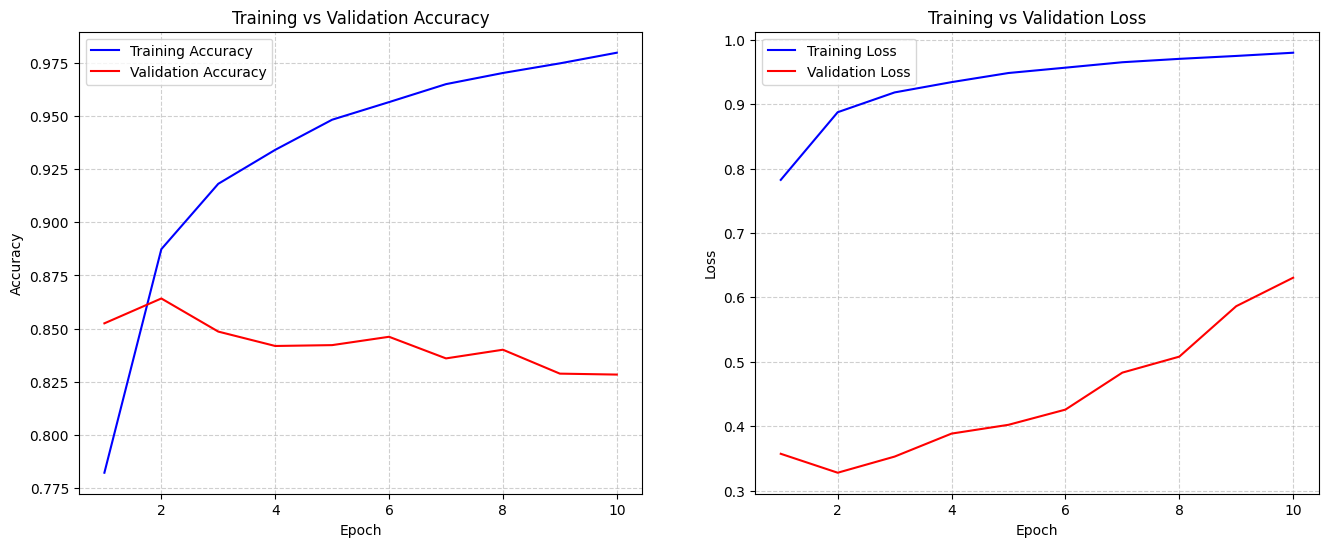

In [30]:
# Now lte's plot the results

acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs = range(1, len(acc) + 1)

plt.figure(figsize=(16, 6)) # Bigger figure

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, "b", label="Training Accuracy")
plt.plot(epochs, val_acc, "r", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True, linestyle="--", alpha=0.6) #Grid lines
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(epochs, acc, "b", label="Training Loss")
plt.plot(epochs, val_loss, "r", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6) #Grid lines

plt.show()

### Key points from the Training & Validation Curves

* **Training accuracy increases steadily**, reaching almost **0.98**, which shows the model is learning patters in the training dta very effectively.

* **Validation accuracy peaks early** (around epoch 2 at ~0.86) and then **gradually declines,** indicating the model stops improving on useen data.

* **Trainig loss decreases**, which is expected as the model becaomes better and fitting tyhe training set.

* **Validatiopn loss increases after the first few epochs**, a clear sigh that the model is starting to overfit.

* The gap between training and validation performance becomes larger over time, showing that the model is memorizing the training data rather than generaliuzing.

* This behavior is **typical for a simple baseline model** (Embedding + GloablAveragePoolling + Dense), which learns quickly but laks teh capacity to capture deeper patters.

* The results confirms that the **preprocessing pipeline works correctly**, and the baseline model provides a **solid benchmark** for complaring modere advanced architectures like LSTM, GRU, CNN, or BiLSTM.

### Word Clouds for Positive and Negative Reviews

To explore the vocabulary patters in the IMDb dataset, we generate two clouds from a single batch of vectorized sequences:

* One for **positive reviews** (label = 1)
* One for **negative reviews** (label = 0)

Because `train_bathces` contains **integer-encoded sequences**, we first convert them back into text using the vocabulary from the `TextVectorization` layer. A word cloud displays each word with a size proporcional to its frequency, helping us visualize which temrs appear most often in each sentiment class.

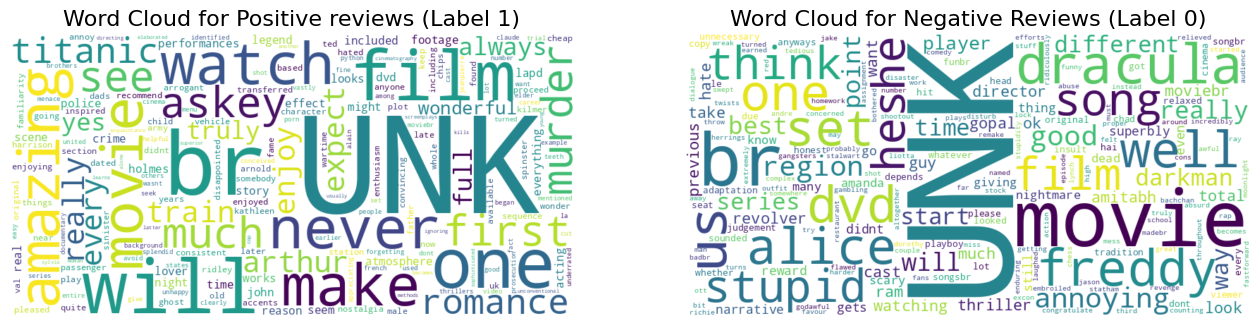

In [32]:
from wordcloud import WordCloud

# 1. Get vocabulary from the TextVectorization layer
vocab = vectorizer_layer.get_vocabulary()

# 2. Helper function to decode integer sequences back to text
def decode_sequence(sequence):
    return " ".join([vocab[i] for i in sequence if i != 0])

# 3. take one batch from train_batches
for batch_x, batch_y in train_batches.take(1):
    sample_sequences = batch_x.numpy()
    sample_labels = batch_y.numpy()   # <-- FIXED HERE

# 4. Separate decoded reviews by label
positive_reviews = []
negative_reviews = []

for seq, label in zip(sample_sequences, sample_labels):
    text = decode_sequence(seq)
    if label == 1:
        positive_reviews.append(text)
    else:
        negative_reviews.append(text)

# 5. Combine into a single strings
positive_text = " ".join(positive_reviews)
negative_text = " ".join(negative_reviews)

# 6. Generate word clouds
wc_positive = WordCloud(width=800, height=400, background_color="white").generate(positive_text)
wc_negative = WordCloud(width=800, height=400, background_color="white").generate(negative_text)

# 7. Plot both word clouds
plt.figure(figsize=(16, 8))

plt.subplot(1, 2, 1)
plt.imshow(wc_positive, interpolation="bilinear")
plt.title("Word Cloud for Positive reviews (Label 1)", fontsize=16)
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(wc_negative, interpolation="bilinear")
plt.title("Word Cloud for Negative Reviews (Label 0)", fontsize=16)
plt.axis("off")

plt.show()


### Top 20 Most frequent Words in Positive and Negative Reviews

To complement the word cloudsm we generate bar charts showing the **top 20 most frequent words** in:

* Positive reviews (label = 1)
* Negative reviews (label = 0)

These charts provide a more quantitative view of the vocabulary patters in each sentiment class. While word clouds highlight general trends, bar charts allo us to compare exact word frequencies and identify whcih terms dominate each category.

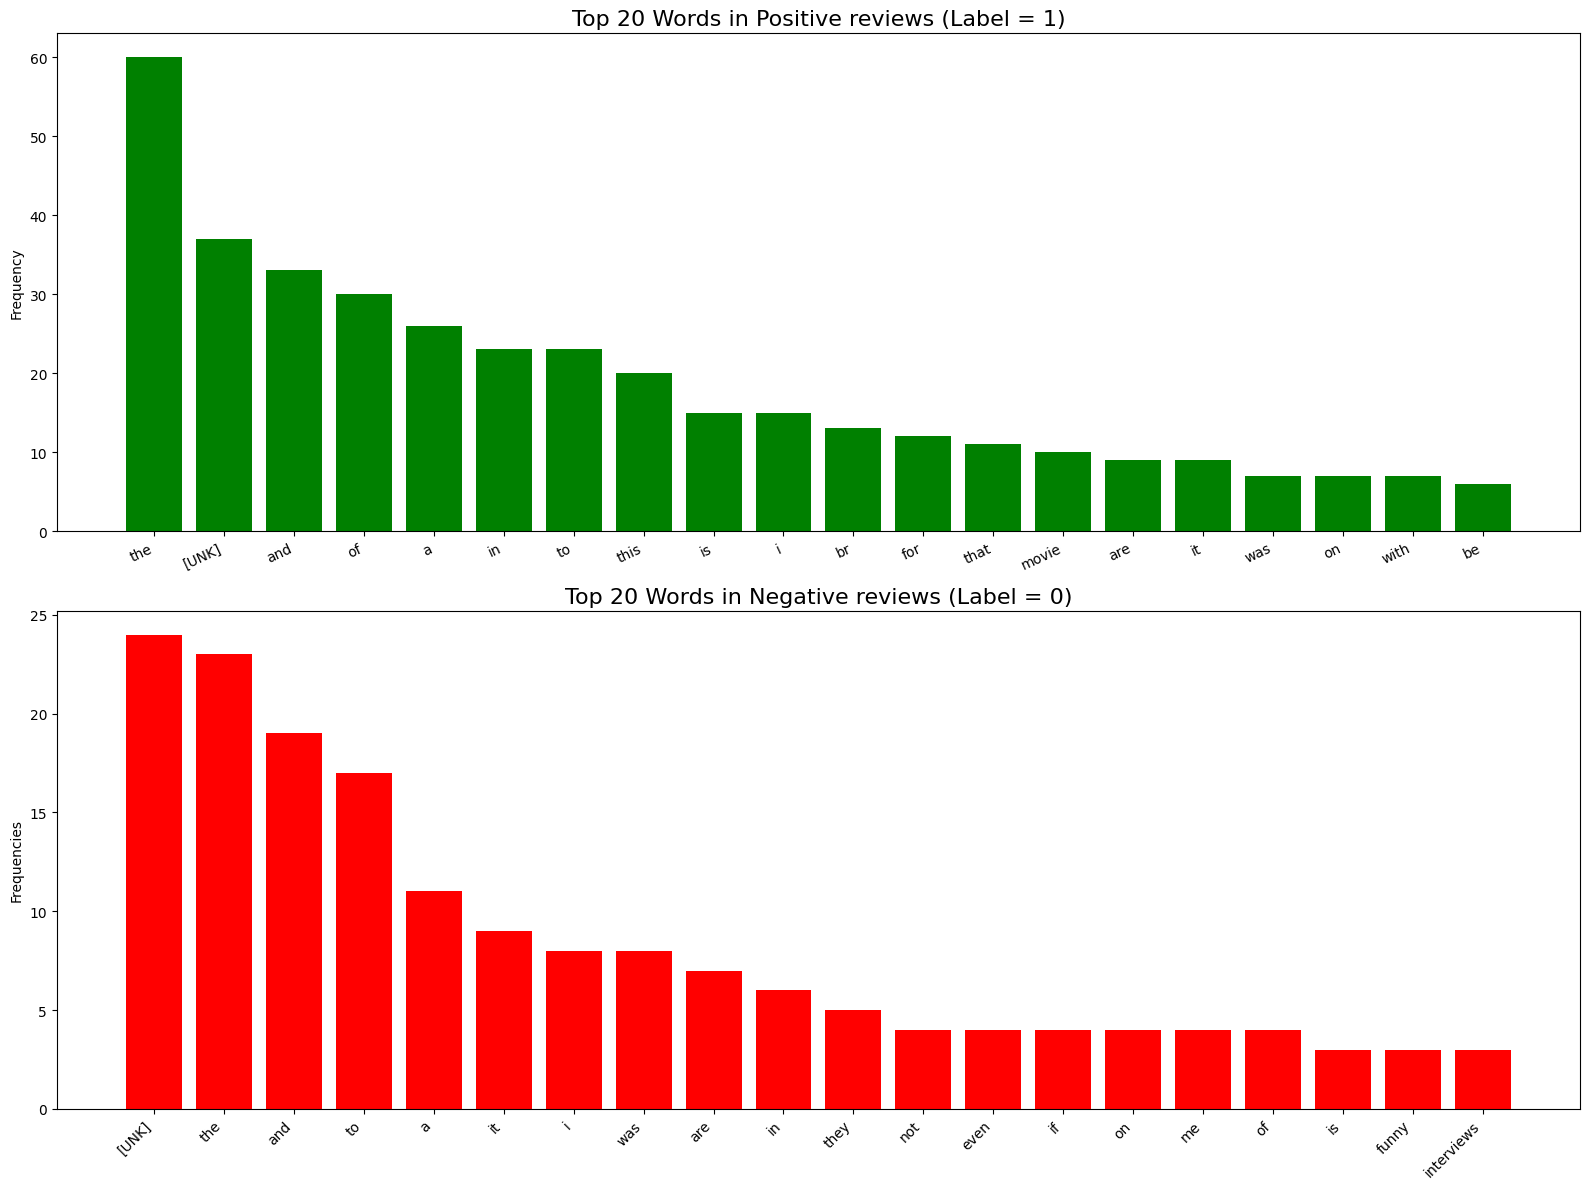

In [33]:
import numpy as np
from collections import Counter

# 1. Get tvocabulary fr4om the TextVectorization layer

vocab = vectorizer_layer.get_vocabulary()

# 2 Hekper function to decode integer sequences back to text
def decode_sequence(sequence):
  return " ".join([vocab[i] for i in sequence if i != 0])

# 3 take one bathc from train_batches
for batch_x, batch_y in train_batches.take(1):
  sample_sequences = batch_x.numpy()
  sample_labels = batch_y.numpy()

# 4 Separate decoded reviews by label
positive_reviews = []
negative_reviews = []

for seq, label in zip(sample_sequences, sample_labels):
  text = decode_sequence(seq)
  if label == 1:
    positive_reviews.append(text)
  else:
    negative_reviews.append(text)

# 5 Tokenize words
positive_words = " ".join(positive_reviews).split()
negative_words = " ".join(negative_reviews).split()

# 6 Count word frequencies
pos_counts = Counter(positive_words)
neg_counts = Counter(negative_words)

# 7 get top 20 words.
top_pos = pos_counts.most_common(20)
top_neg = neg_counts.most_common(20)

# 8 Plogt bar charts
plt.figure(figsize=(16, 12))

# Positive words
plt.subplot(2, 1, 1)
words_pos, counts_pos = zip(*top_pos)
plt.bar(words_pos, counts_pos, color="green")
plt.title("Top 20 Words in Positive reviews (Label = 1)", fontsize=16)
plt.xticks(rotation=25, ha="right")
plt.ylabel("Frequency")

# Negative words
plt.subplot(2, 1, 2)
words_neg, counts_neg = zip(*top_neg)
plt.bar(words_neg, counts_neg, color="red")
plt.title("Top 20 Words in Negative reviews (Label = 0)", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Frequencies")

plt.tight_layout()
plt.show()